## Validate 22MW turbine interpolations

In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wrf_io import postproc
from MITRotor import IEA22MW, BEMGeometry

In [56]:
blue   = sns.color_palette("tab10")[0]
orange = sns.color_palette("tab10")[1]

In [57]:
fontsize = 20
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 
plt.rcParams['figure.dpi']      = 300

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [58]:
rotor = IEA22MW()
geom  = BEMGeometry(Nr=37,Ntheta=224,R=rotor.R, Rhub=rotor.hub_radius)


In [59]:
# r/R from WRF
r = np.array([4.269128E-02,6.891892E-02,9.514655E-02,0.121374,0.147601,0.173829,0.200057,0.226284,0.2525124,0.2787400,0.3049677,0.3311953,0.3574230,0.3836506,0.4098783,0.4361059,0.4623336,0.4885612,0.5147888,0.5410165,0.5672441,0.5934716,0.6196992,0.6459268,0.6721544,0.6983820,0.7246097,0.7508373,0.7770649,0.8032925,0.8295200,0.8557476,0.8819752,0.9082029,0.9344305,0.9606582,0.9868859])

In [60]:
# Airfoil ID at each r/R from WRF
airfoil_ID = np.array([1,2,3,5,6,8,8,9,10,10,10,10,11,11,11,11,11,12,12,12,12,12,12,12,13,13,13,13,13,13,13,13,14,14,14,14,14])

In [61]:
# Verify MITRotor and WRF compute the same airfoil ID at each r/R
rotor.airfoil_func.airfoil_id_from_interp(r) == airfoil_ID

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

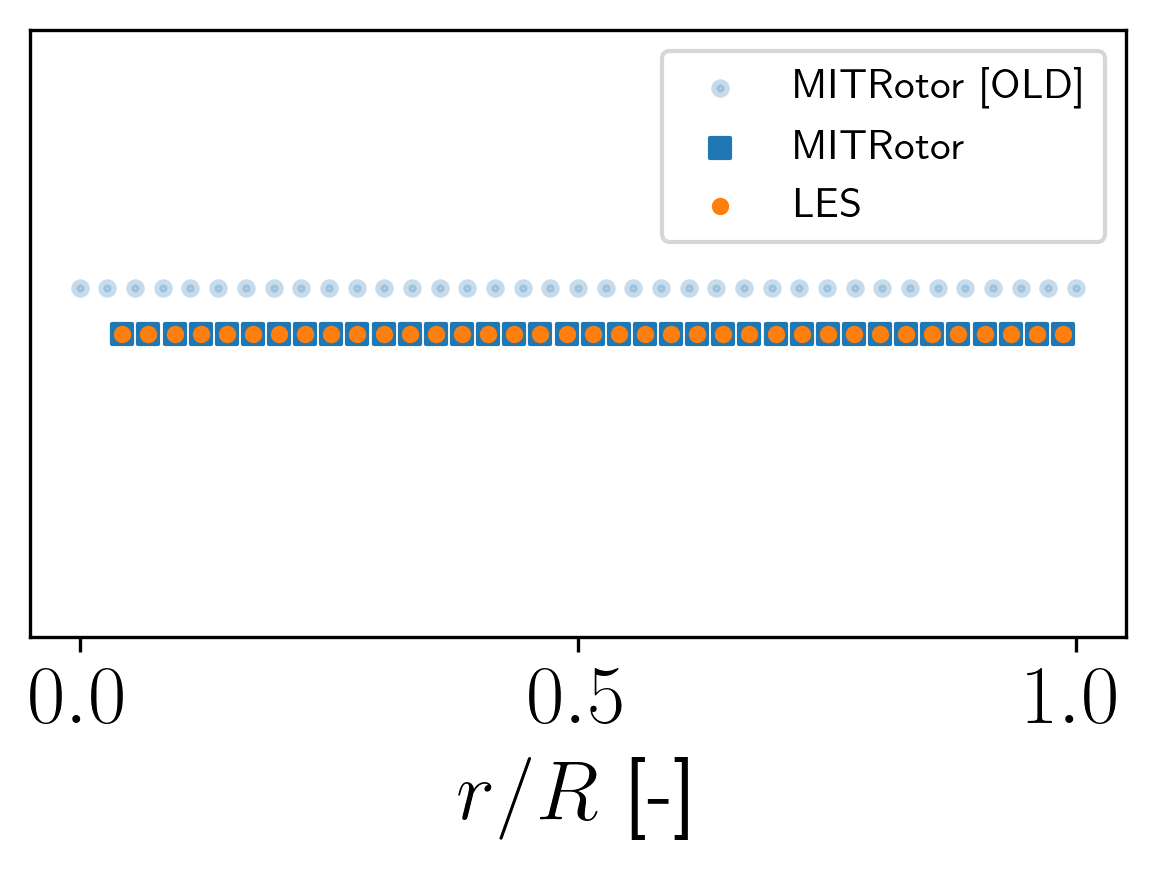

In [72]:
fig, ax = plt.subplots(figsize=(4, 3))


ax.scatter(np.linspace(0,1,37),0.15*np.ones_like(r), 15,zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.',label='MITRotor [OLD]')
ax.scatter(geom.mu,0*np.ones_like(r),25,marker='s', color=blue,label='MITRotor')
ax.scatter(r,0*np.ones_like(r),10,marker='o', color=orange,label='LES')

ax.set_yticks([])

ax.set_ylim([-1,1])
ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
# ax.set_ylabel('Airfoil index',fontsize=fontsize)
ax.legend()
plt.tight_layout()
plt.show()

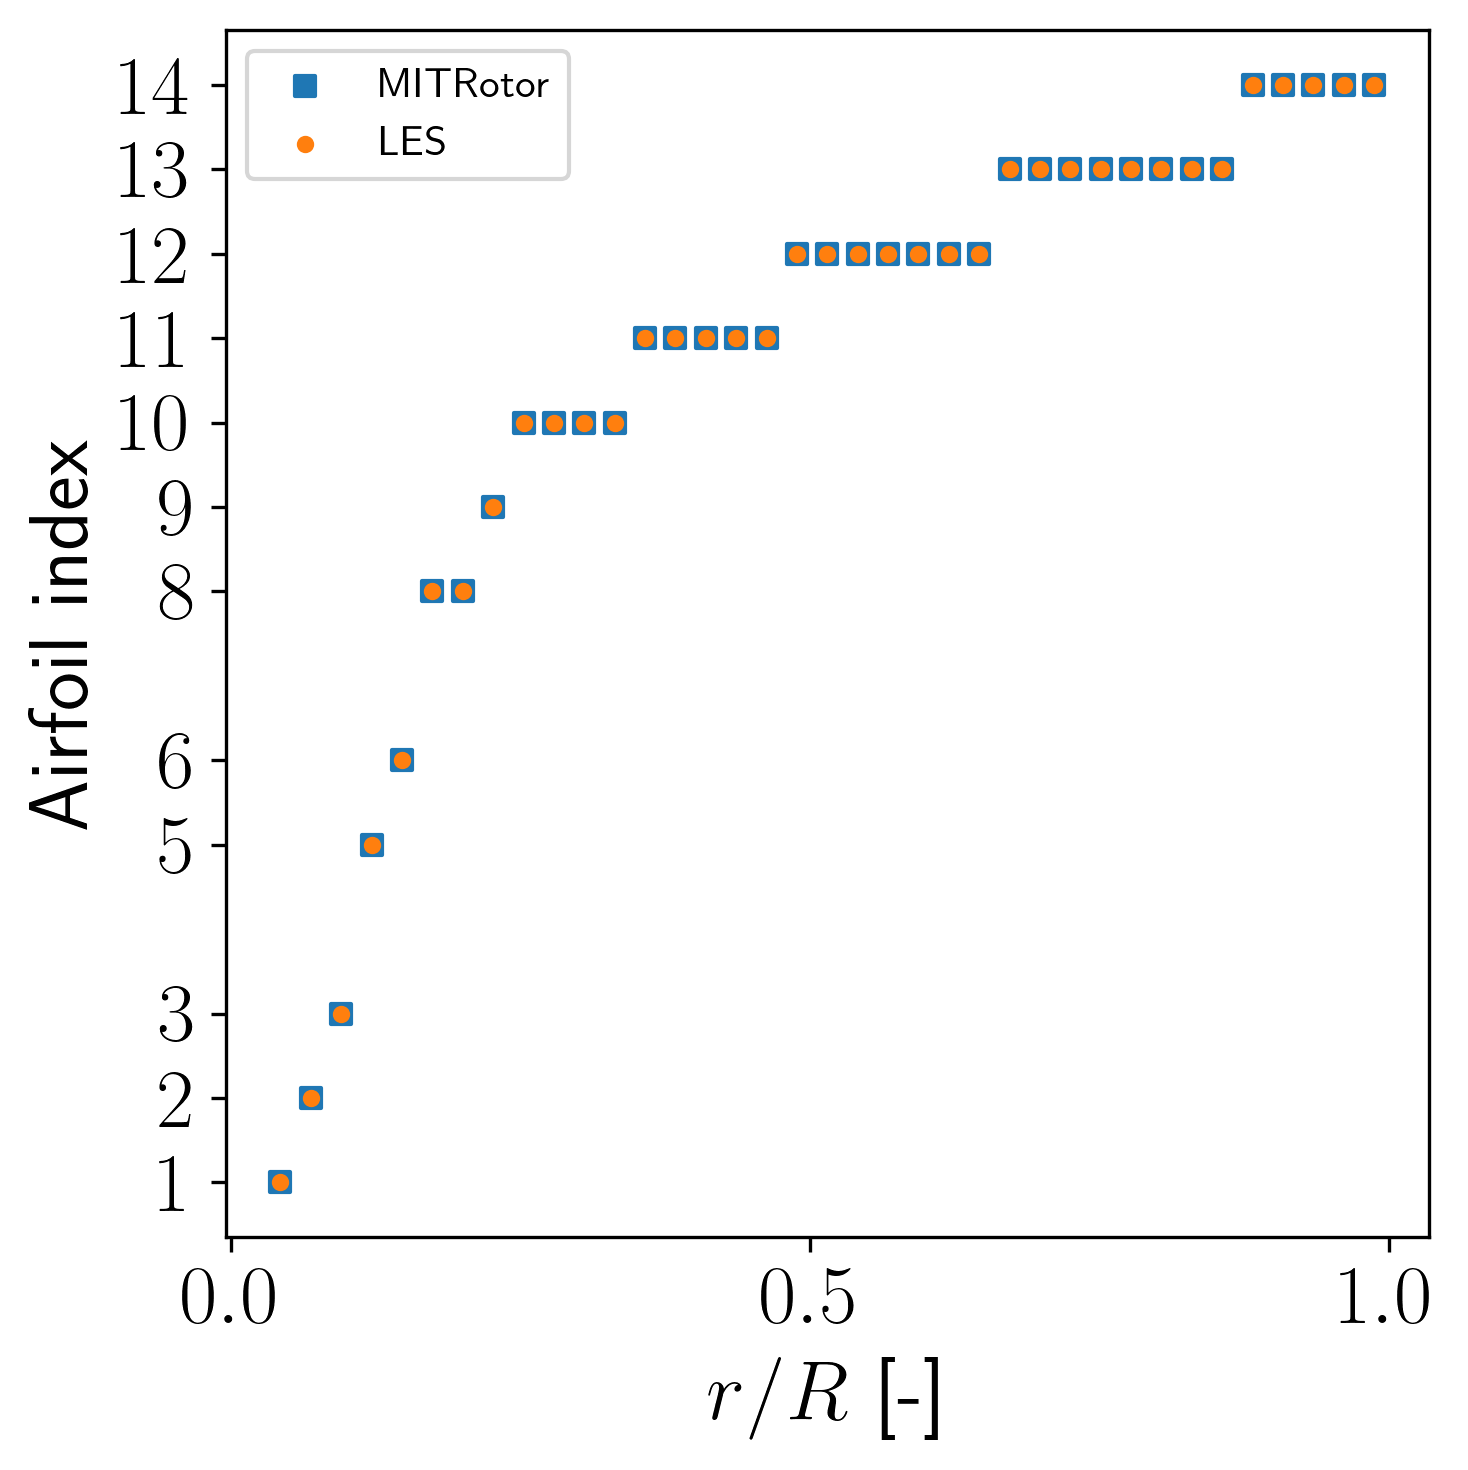

In [63]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(r,rotor.airfoil_func.airfoil_id_from_interp(r),25,marker='s', color=blue,label='MITRotor')
ax.scatter(r,airfoil_ID,10,marker='o', color=orange,label='LES')

unique_ids = np.unique(airfoil_ID)
ax.set_yticks(unique_ids)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Airfoil index',fontsize=fontsize)
ax.legend()
plt.tight_layout()
plt.show()

In [64]:
# airfoil names
airfoil_names = np.array(['circular', 'circular', 'FB90', 'FB80', 'FB70', 'FB60', 'SNL-FFA-W3-560FB', 'SNL-FFA-W3-480FB', 'SNL-FFA-W3-420FB', 'FFA-W3-360', 'FFA-W3-330blend', 'FFA-W3-301', 'FFA-W3-270blend', 'FFA-W3-241', 'FFA-W3-211', 'FFA-W3-211'])
airfoil_names

array(['circular', 'circular', 'FB90', 'FB80', 'FB70', 'FB60',
       'SNL-FFA-W3-560FB', 'SNL-FFA-W3-480FB', 'SNL-FFA-W3-420FB',
       'FFA-W3-360', 'FFA-W3-330blend', 'FFA-W3-301', 'FFA-W3-270blend',
       'FFA-W3-241', 'FFA-W3-211', 'FFA-W3-211'], dtype='<U16')

In [65]:
airfoil_mu = np.array([0.02957746, 0.04898592, 0.07682068, 0.09410385, 0.11056497, 0.12876342, 0.13667594, 0.16196698, 0.18061830, 0.22041432, 0.26923446, 0.41703187, 0.54738404, 0.74666022, 0.98059074, 1.0])
airfoil_mu

array([0.02957746, 0.04898592, 0.07682068, 0.09410385, 0.11056497,
       0.12876342, 0.13667594, 0.16196698, 0.1806183 , 0.22041432,
       0.26923446, 0.41703187, 0.54738404, 0.74666022, 0.98059074,
       1.        ])

In [66]:
airfoil_r = airfoil_mu * rotor.R
airfoil_r

array([  4.19999932,   6.95600064,  10.90853656,  13.3627467 ,
        15.70022574,  18.28440564,  19.40798348,  22.99931116,
        25.6477986 ,  31.29883344,  38.23129332,  59.21852554,
        77.72853368, 106.02575124, 139.24388508, 142.        ])

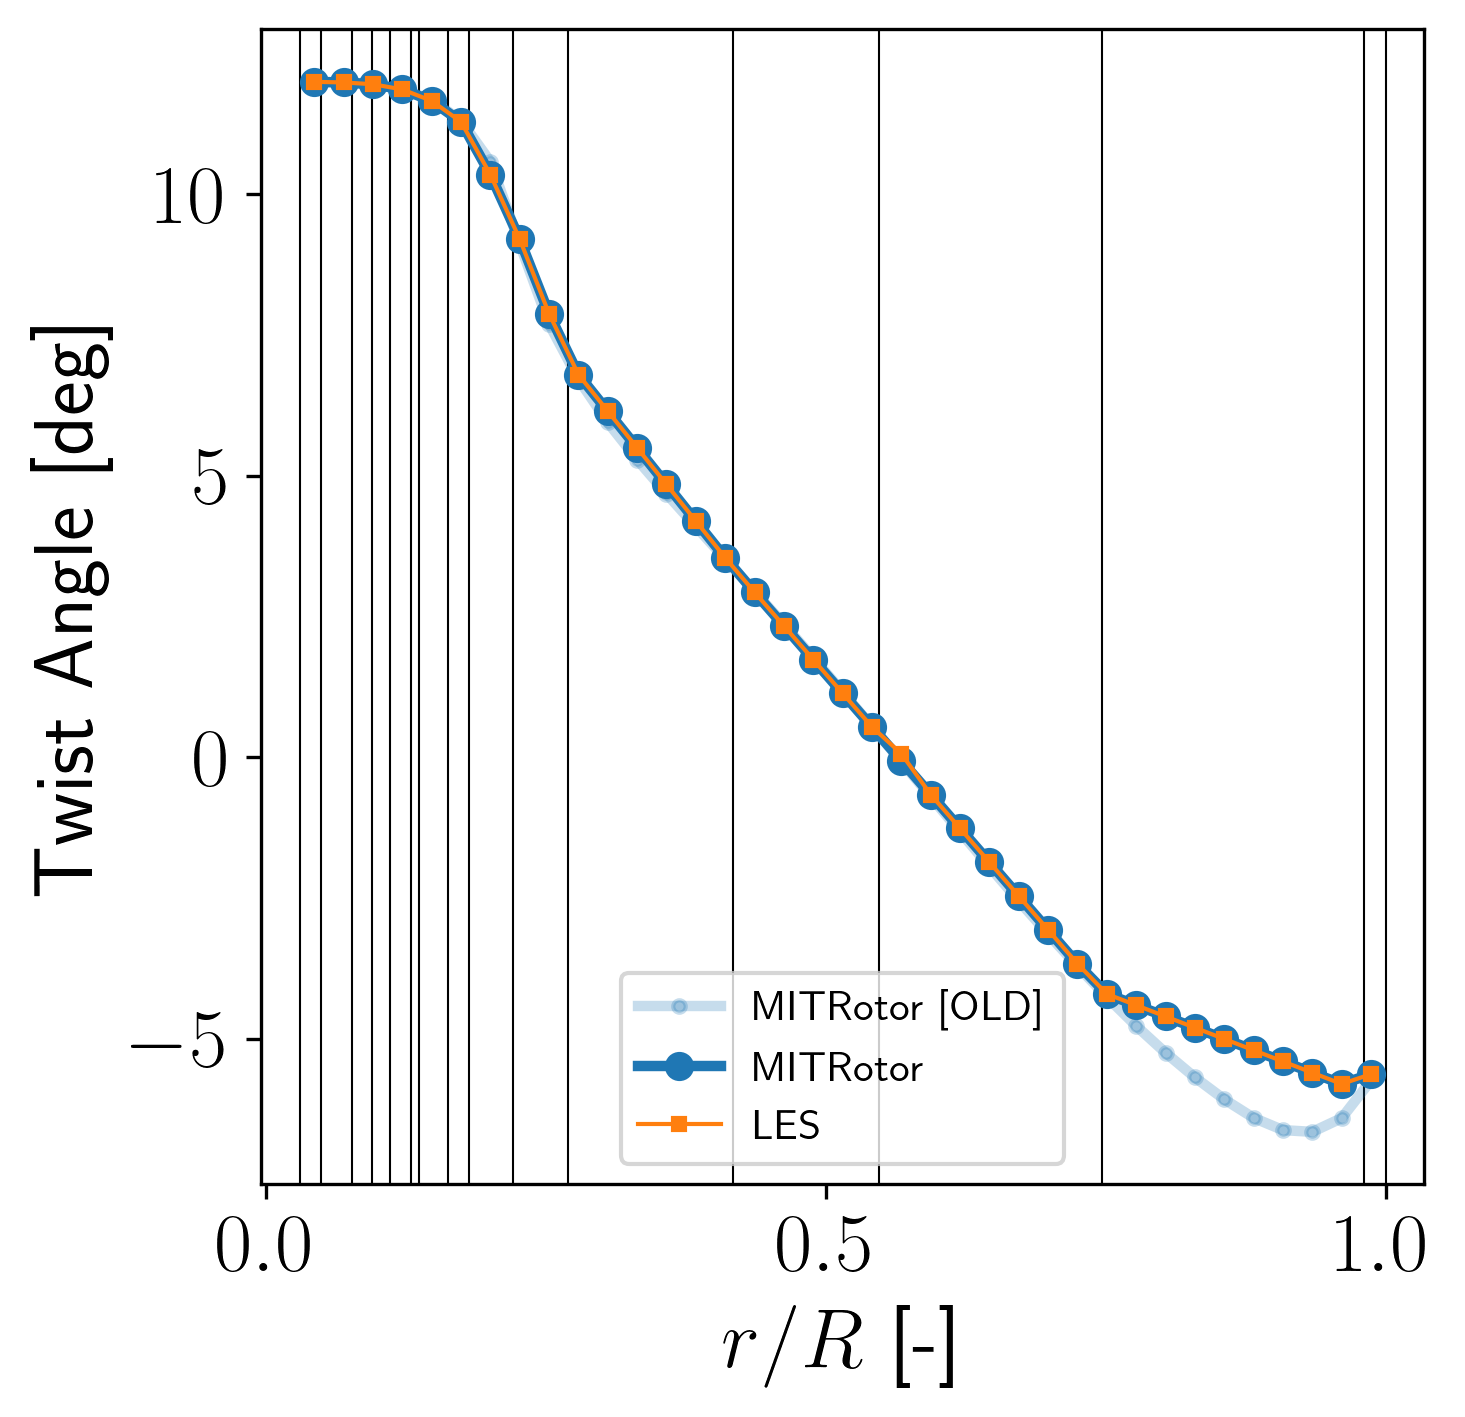

In [67]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r, np.rad2deg(rotor.twist_func_old(r)), zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r, np.rad2deg(rotor.twist_func(r)), zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r, [11.99932    ,11.98905    ,11.95671    ,11.86445    ,11.66193    ,11.28977    ,10.35249    ,9.205230    ,7.879957    ,6.799106    ,6.148094    ,5.497082    ,4.846070    ,4.195058    ,3.544046    ,2.931431    ,2.333225    ,1.735018    ,1.136813    ,0.5386083    ,6.1878562E-02,-0.6630973    ,-1.264316    ,-1.865535    ,-2.466754    ,-3.067972    ,-3.669191    ,-4.206523    ,-4.406429   ,-4.606335    ,-4.806240    ,-5.006145  ,-5.206051    ,-5.405957    ,-5.605863    ,-5.805769    ,-5.631735 ],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Twist Angle [deg]',fontsize=fontsize)
ax.legend()

plt.show()

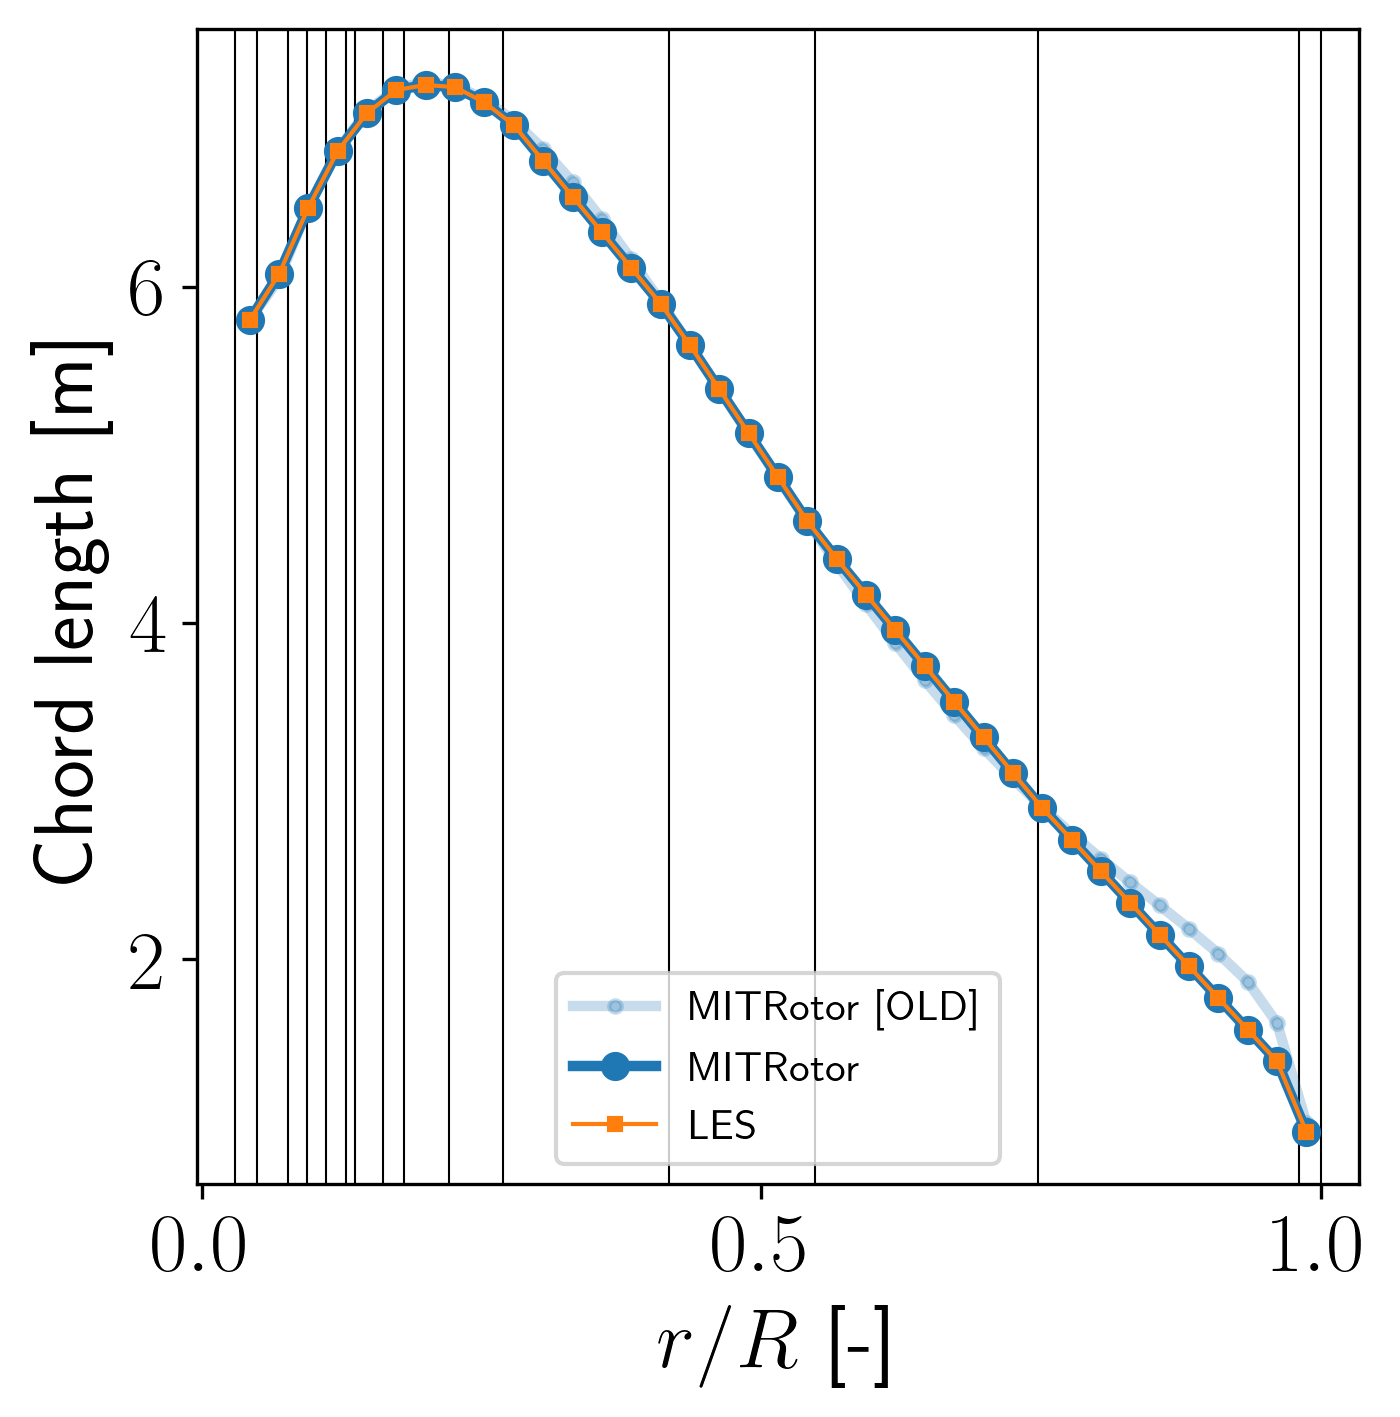

In [68]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r, rotor.chord_func_old(r), zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r,rotor.chord_func(r), zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[5.800000, 6.073525, 6.469741, 6.805879, 7.031432, 7.168149, 7.198850, 7.185217, 7.094581, 6.959846, 6.747562, 6.535279, 6.322995, 6.110711, 5.898427, 5.650439, 5.389053, 5.127666, 4.866279, 4.604893, 4.380842, 4.168770, 3.956698, 3.744627, 3.532555, 3.320483, 3.108411, 2.900116, 2.711770, 2.523424, 2.335078, 2.146732, 1.958385, 1.770039, 1.581693, 1.393346,0.9744712],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Chord length [m]',fontsize=fontsize)
ax.legend()

In [69]:
# Evaluate CL and CD in MITRotor
Cl, Cd = rotor.clcd(r, np.deg2rad(np.array([57.048,46.237,37.397,29.740,23.861,19.885,16.901,14.088,11.941,10.653, 9.753, 9.163, 8.756, 8.445, 8.228, 8.090, 8.057, 8.120, 8.219, 8.346, 8.506, 8.696, 8.922, 9.194, 9.513, 9.851,10.207,10.540,10.589,10.673,10.773,10.897,11.048,11.195,11.320,11.487,11.578])))

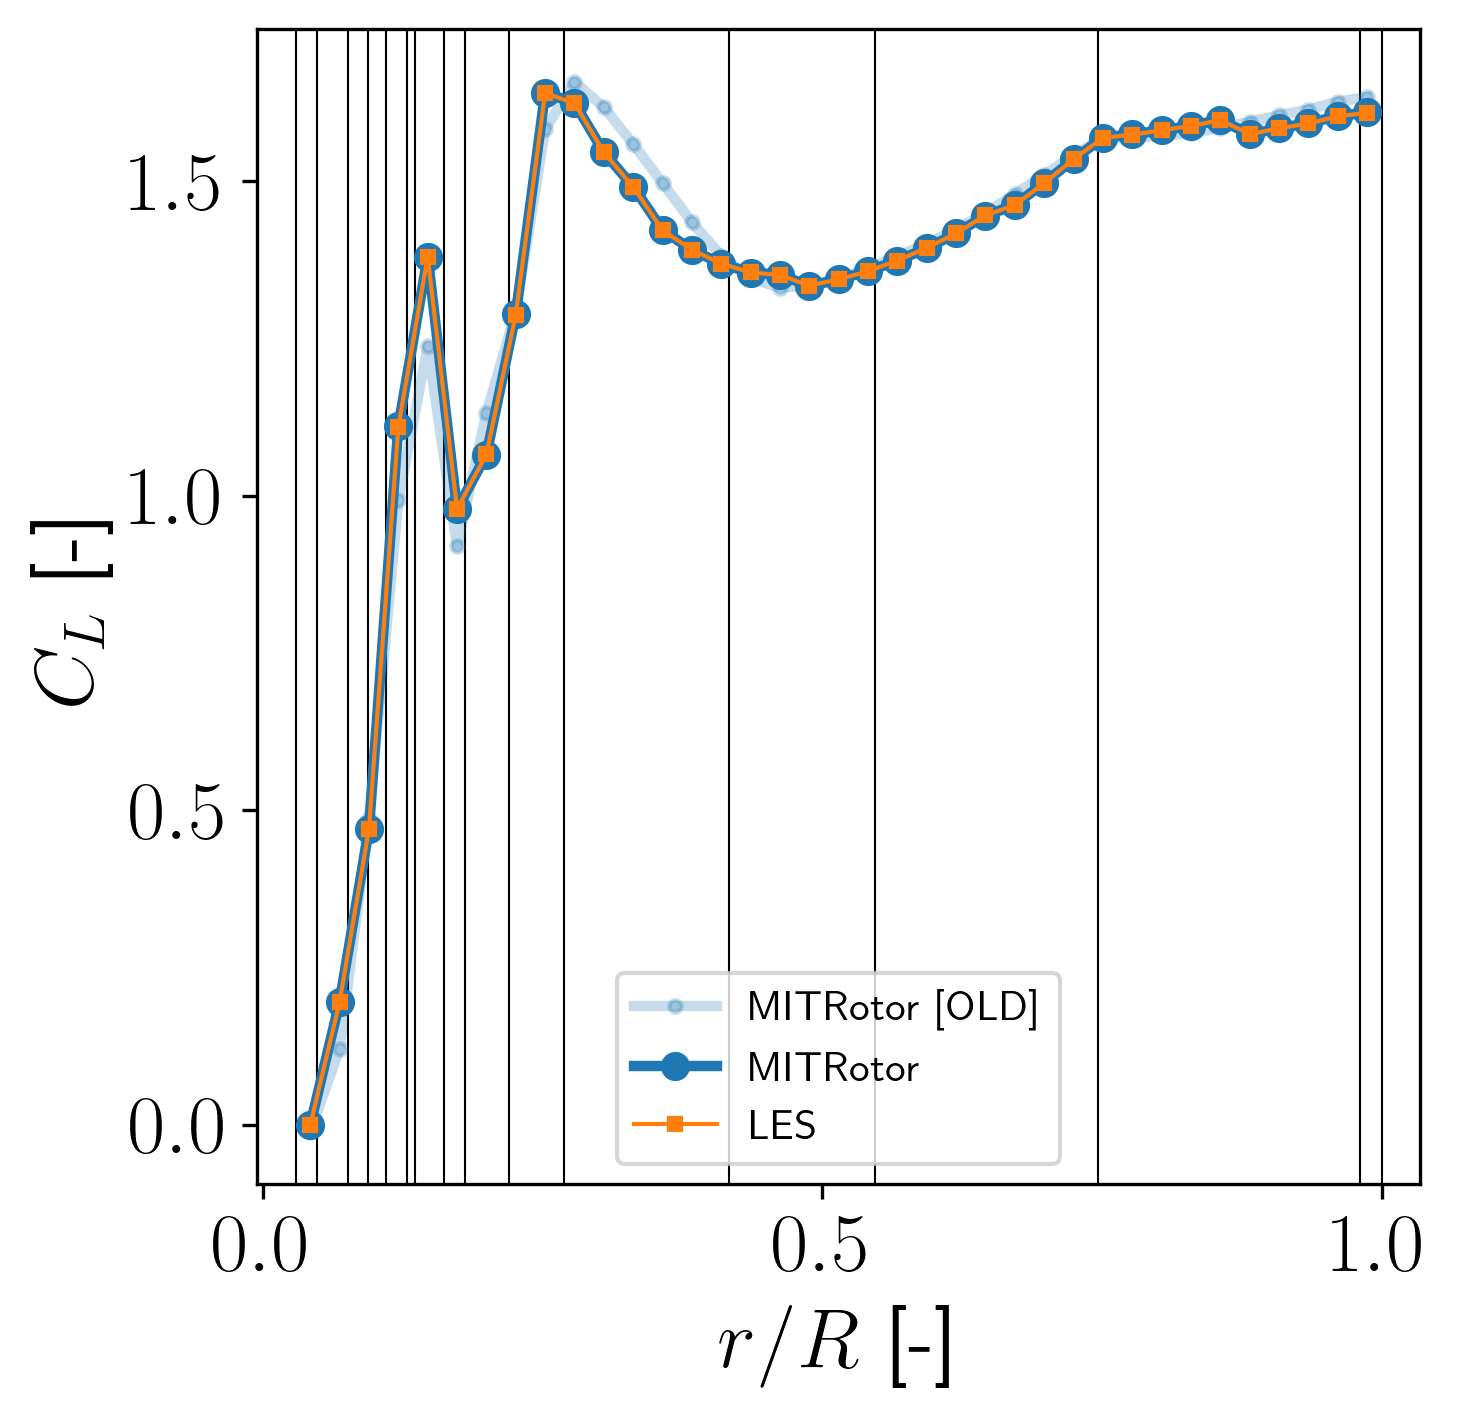

In [70]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r,[-0.01091934,  0.12152174,  0.48635804,  0.99353245,  1.23732984,0.91968475,  1.13200225,  1.29269982,  1.58230807,  1.65798581,1.61764012,  1.55915697,  1.49723004,  1.43484987,  1.38184609,1.34573852,  1.33101411,  1.33408513,  1.34555085,  1.36170962,1.38049343,  1.40082005,  1.42349523,  1.44969085,  1.47952919,1.51007153,  1.54121306,  1.56897403,  1.5686164 ,  1.57182206,1.57678508,  1.58429731,  1.59462412,  1.60491426,  1.61367506,1.62656702,  1.63359112], zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r,Cl, zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[0.000,0.196,0.471,1.110,1.380,0.979,1.066,1.288,1.640,1.624,1.546,1.491,1.422,1.391,1.369,1.355,1.351,1.334,1.344,1.357,1.374,1.394,1.417,1.446,1.462,1.497,1.535,1.569,1.574,1.581,1.588,1.597,1.575,1.584,1.592,1.603,1.609],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('$C_L$ [-]',fontsize=fontsize)
ax.legend()

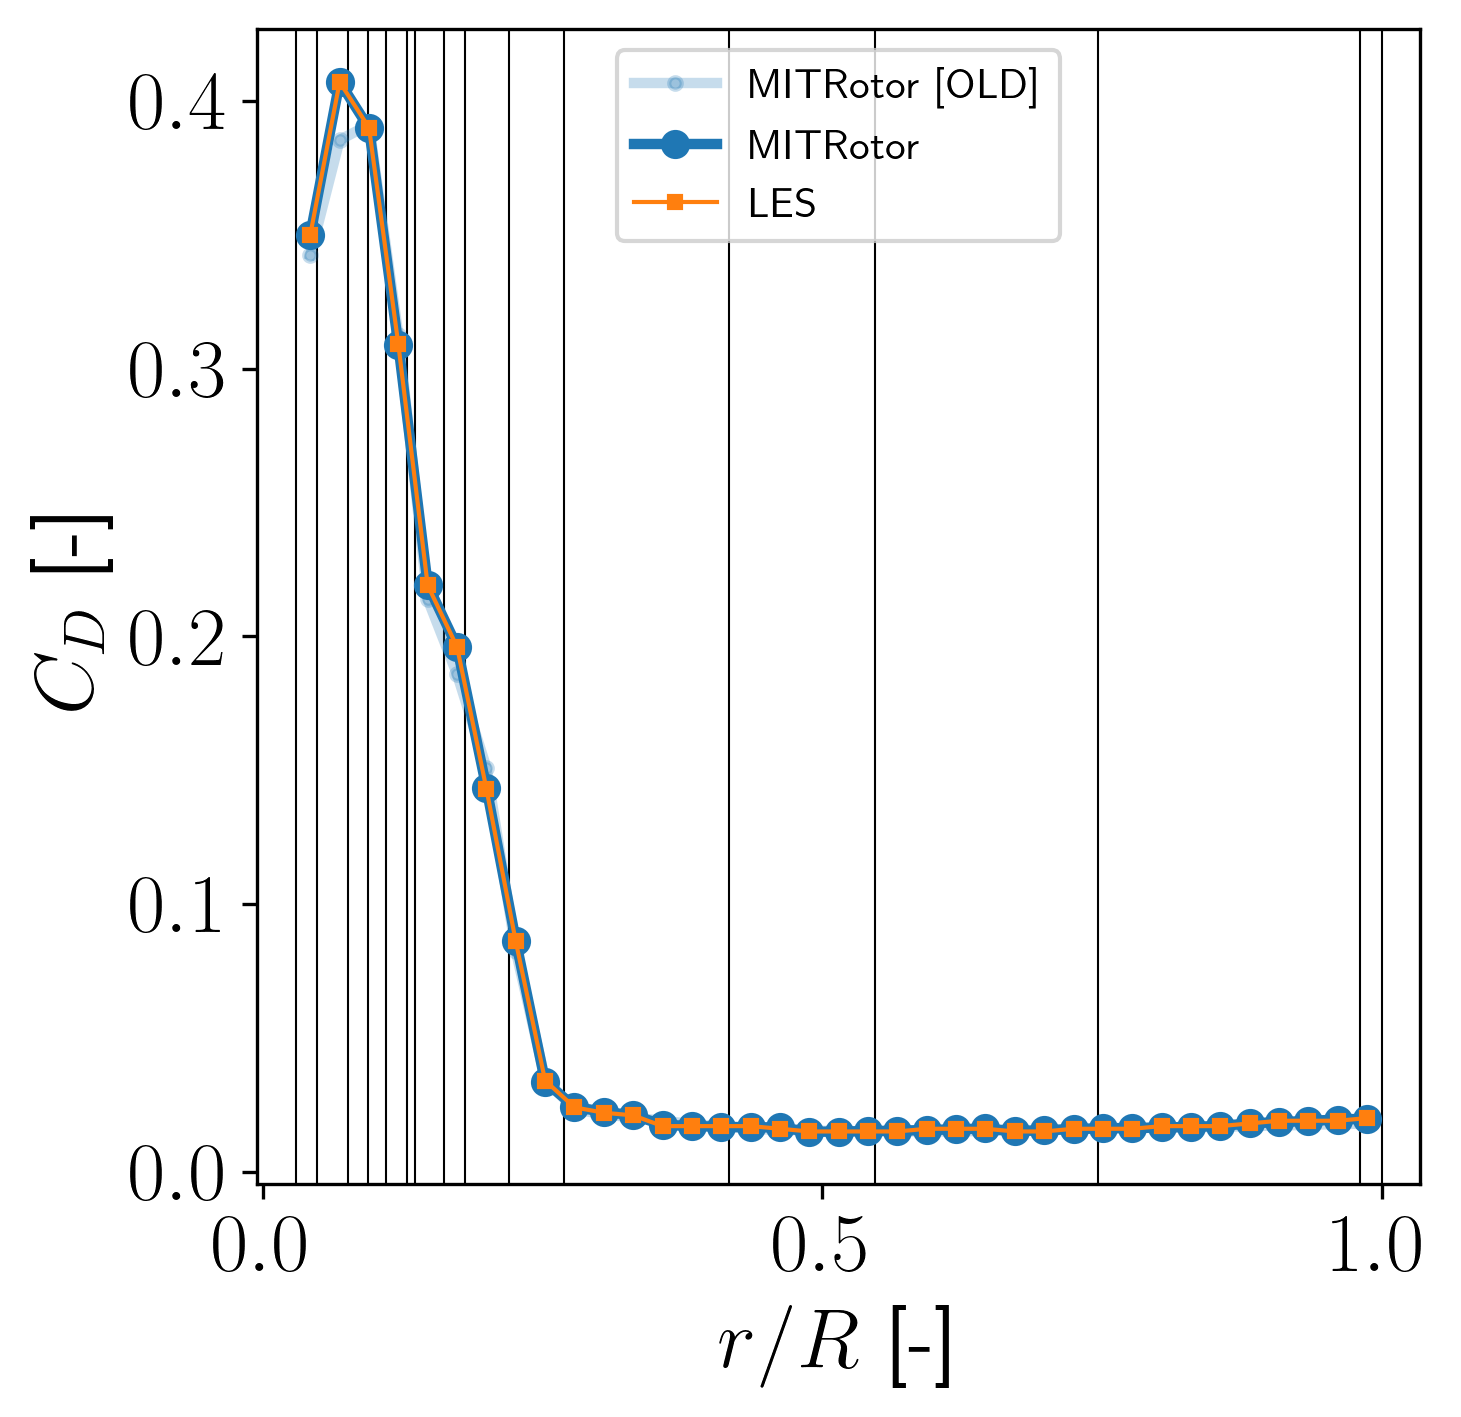

In [71]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r,[0.3424318 , 0.3853855 , 0.39108223, 0.31255392, 0.21378402,0.1857937 , 0.15089048, 0.08253727, 0.03448087, 0.02328634,0.02138574, 0.02021429, 0.01898357, 0.01778344, 0.01678197,0.01604238, 0.01556977, 0.01530121, 0.01514118, 0.01505415,0.0150178 , 0.01501964, 0.01506803, 0.0151774 , 0.01535555,0.01558443, 0.01588079, 0.01621214, 0.01626004, 0.01637681,0.01653418, 0.01673688, 0.01698618, 0.0172388 , 0.01746431,0.01776504, 0.01793908], zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')

ax.plot(r,Cd, zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[0.350,0.407,0.390,0.309,0.219,0.196,0.143,0.086,0.034,0.024,0.022,0.021,0.017,0.017,0.017,0.017,0.016,0.015,0.015,0.015,0.015,0.016,0.016,0.016,0.015,0.015,0.016,0.016,0.016,0.017,0.017,0.017,0.018,0.019,0.019,0.019,0.020],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('$C_D$ [-]',fontsize=fontsize)
ax.legend()